a - 0.7875370424239243 
b - 0.10677062212005925


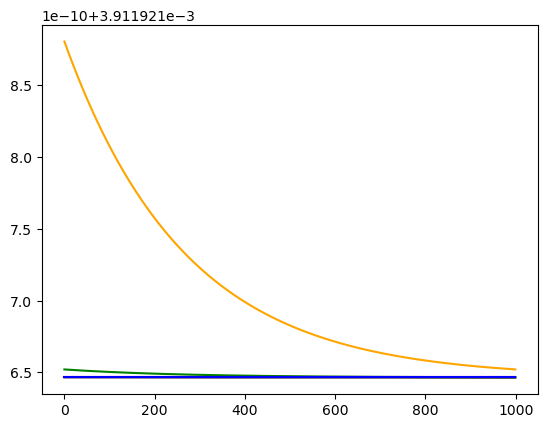

In [37]:
#1) Set learning rate 0.01 and epoch to 10000
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

file = "./dataset/Income3.csv"
data = np.genfromtxt(file, dtype=None, names=True, delimiter=",", encoding = None)

X = data[data.dtype.names[1]]
Y = data[data.dtype.names[2]]

##scale X and Y
normX = (X - X.min(0)) / X.ptp(0)
normY = (Y - Y.min(0)) / Y.ptp(0)

def forward(a, b, X, Y):
       
    m = X.shape[0] # Number of elements in X
    Y_pred, cost, D_a, D_b = 0,0,0,0
    
    ## Uncomment the following lines and fill in with your answer   
    ## The predicted value of Y
    
    Y_pred = a * X + b
    
    ## Calculate the cost
    
    cost = (1/m) * np.sum(np.square((Y_pred - Y)))
    
    ## Calculate Derivative a, b
    D_a = (2 / m) * np.sum((Y_pred - Y) * X)
    D_b = (2 / m) * np.sum(Y_pred - Y)    
    
    return {
        "Y_pred" : Y_pred,
        "cost" : cost,
        "D_a" : D_a,
        "D_b" : D_b
    }

def gradient( X, Y, learning_rate = 0.001, epoch = 50000):
    a = 0.1
    b = 0.1
    
    cost = np.zeros(epoch)
    
    for i in range(epoch): 
        parameters = {}
        
        ## Uncomment the following line and fill in wiht your answer
        
        parameters = forward(a, b, X, Y)
        a = a - learning_rate * parameters["D_a"]  # Update a
        b = b - learning_rate * parameters["D_b"]  # Update b
        cost[i] = parameters["cost"]
        
    return a, b, cost


learning_rate = 0.01
epoch = 10000


#2) Call gradient function to calculate and display a, b and cost

a, b, cost = gradient(normX, normY, learning_rate, epoch)

print ("a - " + str(a), "\nb - " + str(b))

#3) Plot different range of cost data

plt.plot(cost[5000:6000], color='orange')
plt.plot(cost[6000:7000], color='green')
plt.plot(cost[7000:8000], color='black')
plt.plot(cost[8000:9000], color='red')
plt.plot(cost[9000:10000], color='blue')
plt.show()